# Importing Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re


# Load Data

In [2]:
df = pd.read_csv(r"..\data\new data\balanced_product_reviews.csv", encoding='latin-1')



print("balanced_product_reviews dataset shape:", df.shape)


balanced_product_reviews dataset shape: (10000, 4)


# View Data

In [3]:

print("\nbalanced_product_reviews dataset:")
df.head()
df.tail()
df.sample(5)
df.info()
df.describe()




balanced_product_reviews dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Rating          10000 non-null  int64 
 1   Review          10000 non-null  object
 2   Repeated_Words  10000 non-null  object
 3   ReviewLength    10000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 312.6+ KB


,Rating,ReviewLength
count,10000.000000,10000.000000
mean,3.000000,654.995600
std,1.414284,601.128969
min,1.000000,10.000000
25%,2.000000,250.000000
50%,3.000000,477.000000
75%,4.000000,855.000000
max,5.000000,4777.000000


#  Selecting Columns

In [4]:
df = df[['Rating','Review']]

print("Final dataset columns:", df.columns)

print("Final dataset shape:", df.shape)


Final dataset columns: Index(['Rating', 'Review'], dtype='object')
Final dataset shape: (10000, 2)


# Data Visualization of balanced Data

# Rating Distribution (Bar Chart)

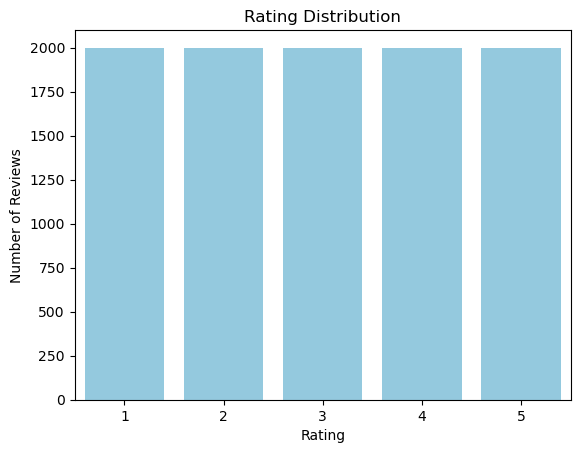

In [5]:
sns.countplot(x='Rating', data=df, color='skyblue')  
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')
plt.show()

# Rating Distribution (Pie Chart)

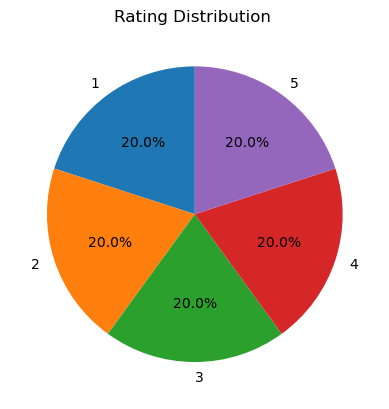

In [6]:

rating_counts = df['Rating'].value_counts().sort_index()

# Labels and values
categories = rating_counts.index
values = rating_counts.values

# Plot pie chart
plt.pie(values, labels=categories, autopct='%1.1f%%', startangle=90)
plt.title("Rating Distribution ")
plt.show()


# Natural Language Processing (NLP)

# Lowercase All Text

In [7]:
df = df[['Rating', 'Review']]
# Convert Review text to lowercase
df['Review'] = df['Review'].str.lower()
# Reset index
df.reset_index(drop=True, inplace=True)

print(df.head())
print("Dataset shape:", df.shape)


   Rating                                             Review
0       1  cool kid club snotty nosed rich kids run aroun...
1       1  donuts are really good if they have any when y...
2       1  awful not sure it classifies as food burrito c...
3       1  absolutely disgusting i had enchiladas and a t...
4       1  they served us stale rice average main dishes ...
Dataset shape: (10000, 2)


# Remove URL

In [8]:
def remove_url(text):
    url_pattern = re.compile(r'https?://\S+|www\.\S+')
    return url_pattern.sub('', text)  # Replace URLs with empty string

df['Review'] = df['Review'].apply(remove_url)

df['Review'].head()


0    cool kid club snotty nosed rich kids run aroun...
1    donuts are really good if they have any when y...
2    awful not sure it classifies as food burrito c...
3    absolutely disgusting i had enchiladas and a t...
4    they served us stale rice average main dishes ...
Name: Review, dtype: object

# Remove HTML tags

In [9]:
def remove_html_tags(text):
    pattern = re.compile('<.*?>')
    return pattern.sub(r'',text)
df['Review'] =df['Review'].apply(remove_html_tags)

df['Review'].head()

0    cool kid club snotty nosed rich kids run aroun...
1    donuts are really good if they have any when y...
2    awful not sure it classifies as food burrito c...
3    absolutely disgusting i had enchiladas and a t...
4    they served us stale rice average main dishes ...
Name: Review, dtype: object

# Remove emojis, punctuation and special characters

In [10]:
import string

punctuation_list = string.punctuation
print(f'The punctuations are {punctuation_list}')



The punctuations are !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


In [11]:
def clean_text_punct(text):
    # Remove punctuation
    for char in punctuation_list:
        text = text.replace(char, '')
    # Remove extra spaces
    text = ' '.join(text.split())
    return text

df['Review'] = df['Review'].apply(clean_text_punct)
df['Review'].head()

0    cool kid club snotty nosed rich kids run aroun...
1    donuts are really good if they have any when y...
2    awful not sure it classifies as food burrito c...
3    absolutely disgusting i had enchiladas and a t...
4    they served us stale rice average main dishes ...
Name: Review, dtype: object

# Showing stopwords 

In [12]:
import spacy
nlp = spacy.load("en_core_web_sm")

def show_stopwords_in_text(text):
    doc = nlp(text)
    present_stopwords = [token.text for token in doc if token.is_stop]
    return present_stopwords

df['Stopwords_in_Review'] = df['Review'].apply(show_stopwords_in_text)
df[['Review', 'Stopwords_in_Review']].head()

,Review,Stopwords_in_Review
0,cool kid club snotty nosed rich kids run aroun...,"[around, than, if, you]"
1,donuts are really good if they have any when y...,"[are, really, if, they, have, any, when, you, ..."
2,awful not sure it classifies as food burrito c...,"[not, it, as, of, a, and, no, they, you, anyth..."
3,absolutely disgusting i had enchiladas and a t...,"[i, had, and, a, just, to, give, them, a, this..."
4,they served us stale rice average main dishes ...,"[they, us, not, as, not, enough, in, the]"


In [13]:
df['Stopword_Count'] = df['Stopwords_in_Review'].apply(len)


df[['Review', 'Stopwords_in_Review', 'Stopword_Count']].head()


,Review,Stopwords_in_Review,Stopword_Count
0,cool kid club snotty nosed rich kids run aroun...,"[around, than, if, you]",4
1,donuts are really good if they have any when y...,"[are, really, if, they, have, any, when, you, ...",31
2,awful not sure it classifies as food burrito c...,"[not, it, as, of, a, and, no, they, you, anyth...",38
3,absolutely disgusting i had enchiladas and a t...,"[i, had, and, a, just, to, give, them, a, this...",33
4,they served us stale rice average main dishes ...,"[they, us, not, as, not, enough, in, the]",8


In [14]:
total_stopwords = df['Stopword_Count'].sum()
print("Total stopwords in all reviews:", total_stopwords)

Total stopwords in all reviews: 699800


# Remove stopwords

In [15]:
def remove_stopwords(text):
    doc = nlp(text)
    filtered_text = " ".join([token.text for token in doc if not token.is_stop])
    return filtered_text

df['Review'] = df['Review'].apply(remove_stopwords)
df['Review'].head()


0    cool kid club snotty nosed rich kids run bosto...
1    donuts good went tuesday morning 1030 total 10...
2    awful sure classifies food burrito consists fl...
3    absolutely disgusting enchiladas taco chance w...
4    served stale rice average main dishes flavorfu...
Name: Review, dtype: object

# Apply Lemmatization

In [16]:
def lemmatize_text(text):
    doc = nlp(text)
    lemma_list = [token.lemma_ for token in doc]   # list format
    lemma_joined = " ".join(lemma_list)            # joined format
    return lemma_list, lemma_joined

# Apply and expand into two columns
df[['Review_List', 'REVIEW']] = df['Review'].apply(lambda x: pd.Series(lemmatize_text(x)))

print("List format:\n", df['Review_List'].head())
print("\nJoined format:\n", df['REVIEW'].head())



List format:
 0    [cool, kid, club, snotty, nosed, rich, kid, ru...
1    [donut, good, go, tuesday, morning, 1030, tota...
2    [awful, sure, classifie, food, burrito, consis...
3    [absolutely, disgusting, enchiladas, taco, cha...
4    [serve, stale, rice, average, main, dish, flav...
Name: Review_List, dtype: object

Joined format:
 0    cool kid club snotty nosed rich kid run boston...
1    donut good go tuesday morning 1030 total 10 do...
2    awful sure classifie food burrito consist flou...
3    absolutely disgusting enchiladas taco chance b...
4    serve stale rice average main dish flavorful m...
Name: REVIEW, dtype: object


# Filter out reviews with: Fewer than minimum words and Excessively long text

In [17]:
# Calculate word count for each review
df['Word_Count'] = df['REVIEW'].apply(lambda x: len(x.split()))

df = df[(df['Word_Count'] >= 3) & (df['Word_Count'] <= 250)]

# Check the filtered dataset
print("Original dataset shape:", df.shape)
print("Filtered dataset shape:", df.shape)
df[['REVIEW', 'Word_Count']].head()


Original dataset shape: (9846, 7)
Filtered dataset shape: (9846, 7)


,REVIEW,Word_Count
0,cool kid club snotty nosed rich kid run boston...,16
1,donut good go tuesday morning 1030 total 10 do...,15
2,awful sure classifie food burrito consist flou...,39
3,absolutely disgusting enchiladas taco chance b...,21
4,serve stale rice average main dish flavorful m...,11


# Visualization 

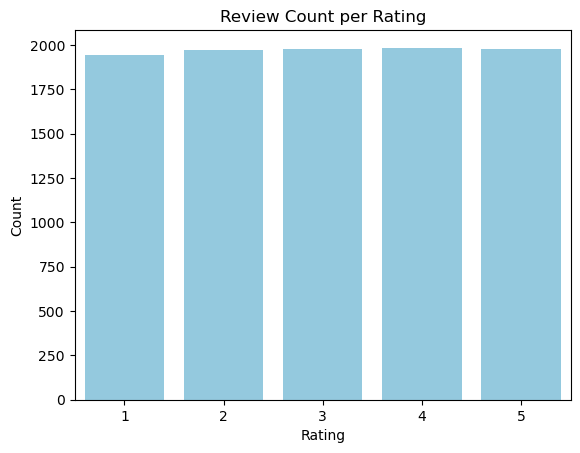

In [18]:
sns.countplot(x='Rating', data=df, color='skyblue')
plt.title('Review Count per Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Create Balanced Dataset

In [19]:
min_count = 2000  

# List to hold balanced DataFrames
balanced_df_list = []

# Loop through each unique rating
for rating in df['Rating'].unique():
    df_rating = df[df['Rating'] == rating][['REVIEW', 'Rating']]
    
    if len(df_rating) < min_count:
        # Oversample minority class (with replacement)
        df_rating_balanced = df_rating.sample(min_count, replace=True, random_state=42)
    else:
        # Undersample majority class (without replacement)
        df_rating_balanced = df_rating.sample(min_count, replace=False, random_state=42)
    
    balanced_df_list.append(df_rating_balanced)

# Concatenate all ratings and shuffle
df_balanced = pd.concat(balanced_df_list).sample(frac=1, random_state=42).reset_index(drop=True)

# Check rating distribution
print("Balanced dataset distribution:\n", df_balanced['Rating'].value_counts())

# Shape of the balanced dataset
print("Balanced dataset shape:", df_balanced.shape)


df_balanced.head()

Balanced dataset distribution:
 Rating
4    2000
3    2000
1    2000
2    2000
5    2000
Name: count, dtype: int64
Balanced dataset shape: (10000, 2)


,REVIEW,Rating
0,book dunkin donuts starbuck tier coffee shop p...,4
1,go sunday morning hangover breakfast mariachi ...,3
2,ask thing m fly land safely fear plane airways...,1
3,nice university ground not grab special like c...,3
4,funny story experience place classmate mention...,3


# Data Visualization

# Bar plot: Review count per rating

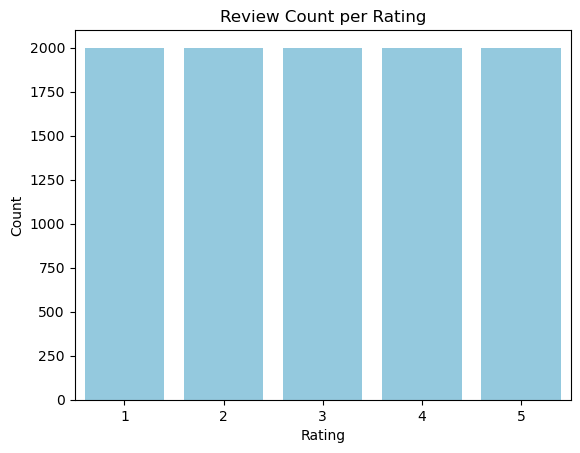

In [20]:
sns.countplot(x='Rating', data=df_balanced, color='skyblue')
plt.title('Review Count per Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Word count 

In [21]:
df_balanced.loc[:, 'Word_Count'] = df_balanced['REVIEW'].str.split().str.len()

df_balanced[['REVIEW', 'Word_Count']].head()



,REVIEW,Word_Count
0,book dunkin donuts starbuck tier coffee shop p...,177
1,go sunday morning hangover breakfast mariachi ...,34
2,ask thing m fly land safely fear plane airways...,65
3,nice university ground not grab special like c...,11
4,funny story experience place classmate mention...,101


# Histogram for Word Count

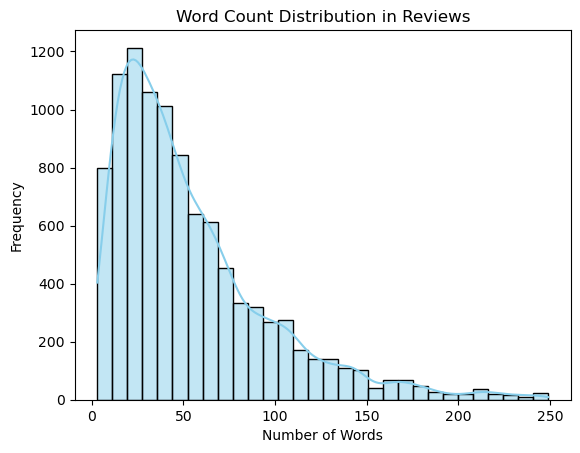

In [22]:

sns.histplot(df_balanced['Word_Count'], bins=30, kde=True, color='skyblue')
plt.title('Word Count Distribution in Reviews')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

# Box Plot: Word count by Rating

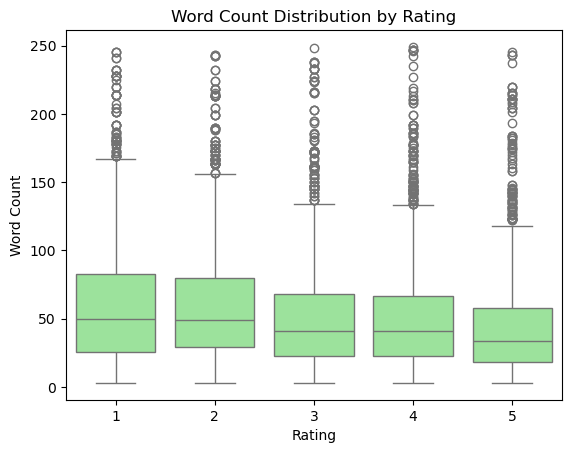

In [23]:


sns.boxplot(x='Rating', y='Word_Count', data=df_balanced, color='lightgreen')
plt.title('Word Count Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Word Count')
plt.show()

# full sample reviews per rating

In [24]:
for rating, group in df_balanced.groupby('Rating'):
    print(f"\n--- Rating: {rating} ---\n")
    sample_reviews = df_balanced[df_balanced['Rating'] == rating]['REVIEW'].sample(
        n=min(5, len(df_balanced[df_balanced['Rating'] == rating])),
        random_state=42)
    for i, review in enumerate(sample_reviews, 1):
        print(f"{i}. {review}\n")



--- Rating: 1 ---

1. wish dagger stab face try eat absolutely bad place entire valley turn ask money embarrassed see drive way home think shot order random item chicken taco onion ring taco like eat horse trough fall apart immediately find try shovel mouth bite realize meat questionably chicken onion ring blah not touch self favor dig near dumpster lunch home pound bottle vegetable oil sure beat hell joint joke

2. work right street go lunch afternoon order salad soon see guy grab shred sandwich lettuce salad tell stop not regret start dig realize lettuce brown yellow disappoint 6 buck nasty lettuce tomato green pepper order salad thinking get like picture website will not return ill pass lunch time coworker opt place

3. huge fan chipotle come location staff look miserable slow cashier decide clean table ring people wait come table clean wait clean rice crunchy like not cook way steak chewy

4. bad dining experience scenery beautiful not complain menu decent good number selection ch

# Shuffle the dataset

In [25]:
# Shuffle the balanced dataset
df_shuffled = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

df_shuffled[['REVIEW', 'Rating']].head()


,REVIEW,Rating
0,pretty damn nice reservation compass opentable...,4
1,good chocolate croissant,5
2,evas place time visit family casa grande prett...,3
3,good time monkey pant celebrate buddy leave ba...,3
4,buy deal live social wait figure d swamp busin...,1


# Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

X = df_balanced['REVIEW']   # Text data
y = df_balanced['Rating']          # Target labels

# Stratified split to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))


Training set size: 8000
Test set size: 2000


# Preprocessing

In [27]:

nlp = spacy.load('en_core_web_sm')

def spacy_preprocess(text):
    doc = nlp(text.lower())  # Lowercase and tokenize
    tokens = [token.lemma_ for token in doc if not token.is_stop and token.is_alpha]
    return ' '.join(tokens)


In [28]:
# Preprocess training set
X_train_processed = X_train.apply(spacy_preprocess)

# Preprocess test set
X_test_processed = X_test.apply(spacy_preprocess)

print("X_train_preprocessed:")
print(X_train_processed.head())
print("X_test_preprocessed:")
print(X_test_processed.head())



X_train_preprocessed:
2203    place bad place live live aug office grate fix...
9737    ripe old age time previous review siesta cours...
8977    okfirst let grow phx special occasion bobby ma...
8396    want like place starter pay cash owe dollar te...
4713    family birthday friday night people dining roo...
Name: REVIEW, dtype: object
X_test_preprocessed:
4220    place bad irs irs admit mistake arrogant worke...
1413    new fry burb awesome old relic pretty bad ugly...
2355    chance experience oscuro amber lager pizza ari...
1988                   good food taiwanese come mean good
6214    brutal hide child ve chipotle ll feel right ho...
Name: REVIEW, dtype: object


# Vectorize text using:TF-IDF

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000,ngram_range=(1,3), stop_words='english')

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_processed)
print("TF-IDF training set shape:", X_train_tfidf.shape)

X_test_tfidf = tfidf_vectorizer.transform(X_test_processed)
print("TF-IDF test set shape:", X_test_tfidf.shape)



TF-IDF training set shape: (8000, 10000)
TF-IDF test set shape: (2000, 10000)


In [30]:
print("Number of features in TF-IDF:", len(tfidf_vectorizer.get_feature_names_out()))
print("Sample features:", tfidf_vectorizer.get_feature_names_out()[:30])


Number of features in TF-IDF: 10000
Sample features: ['aaron' 'abacus' 'abandon' 'abbiamo' 'aber' 'ability' 'able' 'able eat'
 'absolute' 'absolutely' 'absolutely amazing' 'absolutely atrocious'
 'absolutely atrocious starbuck' 'absolutely disgusting' 'absolutely love'
 'absolutely revolt' 'absolutely revolt tattoo' 'abundance' 'ac'
 'academic' 'acceder' 'accent' 'accept' 'acceptable' 'access' 'accessible'
 'accessory' 'accommodate' 'accomodate' 'accompany']


# Original Reviews and Ratings for Training and Test Sets

In [31]:
# Training set
print("REVIEW and Rating from training set:")
train_df_sample = pd.DataFrame({'REVIEW': X_train, 'Rating': y_train}).reset_index(drop=True)
print(train_df_sample.head(), "\n")  # Added \n for separation

# Test set
print("REVIEW and Rating from test set:")
test_df_sample = pd.DataFrame({'REVIEW': X_test, 'Rating': y_test}).reset_index(drop=True)
print(test_df_sample.head())


REVIEW and Rating from training set:
                                              REVIEW  Rating
0  place bad place live live aug 2010 2011 office...       1
1  ripe old age 3 time previous review siesta cou...       4
2  okfirst let grow phx special occasion bobby ma...       3
3  want like place starter pay cash owe dollar te...       1
4  go family birthday friday night people dining ...       1 

REVIEW and Rating from test set:
                                              REVIEW  Rating
0  place bad irs irs admit mistake arrogant worke...       1
1  new fry burb awesome old relic pretty bad ugly...       2
2  chance experience oscuro amber lager pizza ari...       3
3                 good food taiwanese come mean good       5
4  go brutal hide child ve chipotle ll feel right...       1


# Top TF-IDF Features per Review with Corresponding Ratings

In [32]:

def top_tfidf_features_per_review(tfidf_matrix, feature_names, ratings, top_n=5):
  
    # Ensure dense format
    if not isinstance(tfidf_matrix, np.ndarray):
        tfidf_dense = tfidf_matrix.toarray()
    else:
        tfidf_dense = tfidf_matrix

    top_features_list = []

    for i in range(tfidf_dense.shape[0]):
        row = tfidf_dense[i]
        top_indices = row.argsort()[-top_n:][::-1]  # Indices of top N features
        top_features = [feature_names[idx] for idx in top_indices]
        top_scores = [row[idx] for idx in top_indices]
        
        top_features_list.append({
            'Rating': ratings.iloc[i] if hasattr(ratings, 'iloc') else ratings[i],
            'Top_Features': top_features,
            'TF-IDF_Scores': top_scores
        })

    return pd.DataFrame(top_features_list)

feature_names = tfidf_vectorizer.get_feature_names_out()
top_features_df = top_tfidf_features_per_review(X_train_tfidf, feature_names, y_train, top_n=5)

top_features_df.head()


,Rating,Top_Features,TF-IDF_Scores
0,1,"[fix, live, address, gross, office]","[0.3714333709341959, 0.2743969330707127, 0.236..."
1,4,"[equipment, photo, ve, rental, repair]","[0.36601042920681254, 0.2400445935035767, 0.18..."
2,3,"[context, bobby, phx, variety thing, place maybe]","[0.25886459382444243, 0.24828564835151148, 0.2..."
3,1,"[change, pay cash, china chili, chow mein, nig...","[0.22490915543619758, 0.19576246526478122, 0.1..."
4,1,"[clue, clue leave, shrimp, order, surprised wa...","[0.2554509805022034, 0.18890199872852984, 0.11..."


In [33]:
top_features_df.tail()

,Rating,Top_Features,TF-IDF_Scores
7995,1,"[class, money, rep, financial aid, money time]","[0.34213353577255307, 0.2448198736180803, 0.23..."
7996,2,"[sushi, chef, kind, service okay, sushi chef]","[0.38116319491046646, 0.2835577713338725, 0.21..."
7997,2,"[bar, lot, time, live, average price]","[0.20934432581460555, 0.20423990208446316, 0.1..."
7998,4,"[time tour, history great, pretty cool, adult,...","[0.3823697384566267, 0.3823697384566267, 0.328..."
7999,5,"[que, estudiar, verde, te, edificios]","[0.5384062739329433, 0.41173542173002875, 0.35..."


# Convert TF-IDF Matrices to DataFrames

In [34]:

feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert TF-IDF matrix to DataFrame
tfidf_df_train = pd.DataFrame(X_train_tfidf.toarray(), columns=feature_names)

# Add Rating column
tfidf_df_train['Rating'] = y_train.reset_index(drop=True)


tfidf_df_train.head()


,aaron,abacus,abandon,abbiamo,aber,ability,able,able eat,absolute,absolutely,...,zero,zero star,zipp,zone,zoo,zu,zucchini,zucchini shisito,zucchini shisito pepper,Rating
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [35]:
tfidf_df_train.tail()

,aaron,abacus,abandon,abbiamo,aber,ability,able,able eat,absolute,absolutely,...,zero,zero star,zipp,zone,zoo,zu,zucchini,zucchini shisito,zucchini shisito pepper,Rating
7995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
7996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
7997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
7998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
7999,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5


# Training and Evaluation of Machine Learning Models

# Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import pprint

In [58]:
# Initialize the Random Forest model
rf_model = RandomForestClassifier(n_estimators=1000, random_state=42, n_jobs=-1)


In [59]:
# Display all parameters
pprint.pprint(rf_model.get_params())

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 1000,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}


In [60]:

# Train the model
rf_model.fit(X_train_tfidf, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [61]:
# Predict on the test data
y_pred = rf_model.predict(X_test_tfidf)

In [62]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}")

Accuracy: 0.866


In [63]:
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.97      0.94       400
           2       0.96      0.90      0.93       400
           3       0.91      0.86      0.88       400
           4       0.79      0.76      0.77       400
           5       0.77      0.85      0.81       400

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



In [64]:
# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Confusion Matrix:
[[387   5   4   2   2]
 [ 18 358   9   7   8]
 [  4   4 343  24  25]
 [  9   3  18 304  66]
 [  3   3   4  50 340]]


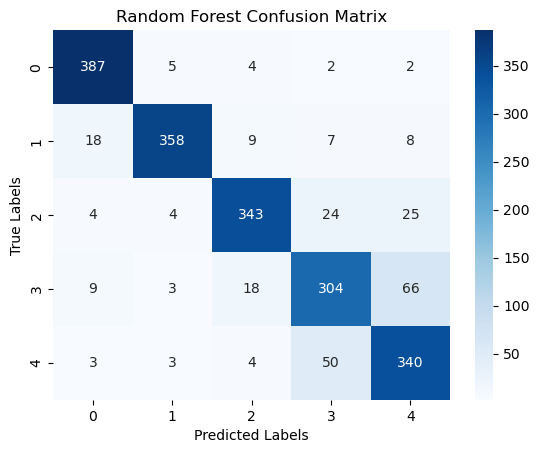

In [65]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()